## Experiment: Stability of Hidden Representations During Training

We begin with a predefined set of probe inputs that remain fixed throughout the experiment. These inputs are used to track how internal representations evolve during training.

### 1. Standard Training

- Train the autoencoder on a nonlinear sequence.
- After every 1000 training steps, pass the predefined probe inputs through the network and extract their hidden representations.
- Compute the L2 distance between the current hidden states and those obtained at the previous checkpoint.
- This measures how much the internal representations drift over time.

### 2. Loss-Thresholded Update

- Repeat the same procedure, but update the model parameters only when the reconstruction loss exceeds a predefined threshold.
- Record the hidden representations every 1000 steps.
- Compute the L2 distance relative to the previous checkpoint.

By comparing representation drift under standard training and loss-thresholded updates, we can evaluate how different update mechanisms affect the stability of learned internal representations.

In [1]:
## Load necessary library files ##

import sys
sys.path.append('..')
from source.utils import get_sequence, DatasetConverter
from source.model.memory import Memory

## Load standard files ##
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from torch import from_numpy as tnsr
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch.nn.functional as F
from tqdm import tqdm
import pickle 

In [2]:
## select device ##
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")  # works only with NVIDIA GPUs (not on Mac)
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: mps


## Visualize the simulation data ##

In [3]:
## load the nonlinear simulation from source files ##
print("A 42 tokens long nonlinear sequence ", get_sequence(42, n_community=2, n_members=3))


A 42 tokens long nonlinear sequence  ABCGDEFGDFEGABCGDFEGDFEGDEFGDEFGDEFGDEFGDE


In [76]:
## define memory parameters ##
input_size = 7
hidden_size = 100
embedding_dim = 30
total_samples = 500000

In [77]:
reps = 10
short_term_memory = 4
lr = 1e-3
repitition = []
dis = []
samples_seen = []

fixed_seq = get_sequence(20, n_community=2, n_members=3)
fixed_data_set = DatasetConverter(fixed_seq, short_term_memory)
fixed_loader = DataLoader(fixed_data_set, batch_size=1, shuffle=False)

for rep in tqdm(range(reps)):
    print("Doing reps ", rep+1)

    hidden_codes_prev = None
    model = Memory(input_size, hidden_size, embedding_dim)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-8)
    criterion = nn.functional.cross_entropy

    data = get_sequence(total_samples, n_community=2, n_members=3)
    data_set = DatasetConverter(data, short_term_memory)
    train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

    h_ = None
    total = 0
    for x, y in train_loader:
        recon_logit, h0, h_ = model(x, h_)
        B, T, V = recon_logit.shape
        recon_loss = nn.functional.cross_entropy(recon_logit.reshape(B*T, V), x.reshape(B*T))
        
        optimizer.zero_grad()  
        recon_loss.backward()

        optimizer.step()

        with torch.no_grad():
            h_ = h_.detach()
            total += 1


            ### extract the hidden states from the trained RNN ###
            if total%1000==0:
                hidden_states = []
                h = None

                for x_fix, _ in fixed_loader:
                    with torch.no_grad():
                        h = model.encode_step_from_token(x_fix[:,-1], h)

                        hidden_states.append(
                            h[0][0].numpy()
                        )
                hidden_states = torch.tensor(hidden_states)

                if hidden_codes_prev != None:
                    drift = (hidden_states - hidden_codes_prev).pow(2).sum(dim=1).sqrt().mean().item()
                    dis.append(drift)
                    
                    repitition.append(rep)
                    samples_seen.append(total)

                hidden_codes_prev = hidden_states.clone()

            
df = pd.DataFrame()
df['reps'] = repitition
df['Drift'] = dis

with open('../pickle_files/memory_drift_not_thresholded.pickle', 'wb') as f:
    pickle.dump(df, f)

  0%|          | 0/10 [00:00<?, ?it/s]

Doing reps  1


 10%|█         | 1/10 [18:27<2:46:07, 1107.52s/it]

Doing reps  2


 20%|██        | 2/10 [36:37<2:26:18, 1097.29s/it]

...

 80%|████████  | 8/10 [2:24:30<35:58, 1079.47s/it]

Doing reps  9


 90%|█████████ | 9/10 [2:42:28<17:59, 1079.11s/it]

Doing reps  10


100%|██████████| 10/10 [3:00:30<00:00, 1083.00s/it]


In [78]:
reps = 10
short_term_memory = 4
lr = 1e-3
repitition = []
dis = []
samples_seen = []

fixed_seq = get_sequence(20, n_community=2, n_members=3)
fixed_data_set = DatasetConverter(fixed_seq, short_term_memory)
fixed_loader = DataLoader(fixed_data_set, batch_size=1, shuffle=False)

for rep in tqdm(range(reps)):
    print("Doing reps ", rep+1)

    hidden_codes_prev = None
    model = Memory(input_size, hidden_size, embedding_dim)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-8)
    criterion = nn.functional.cross_entropy

    data = get_sequence(total_samples, n_community=2, n_members=3)
    data_set = DatasetConverter(data, short_term_memory)
    train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

    h_ = None
    total = 0
    for x, y in train_loader:
        recon_logit, h0, h_ = model(x, h_)
        B, T, V = recon_logit.shape
        recon_loss = nn.functional.cross_entropy(recon_logit.reshape(B*T, V), x.reshape(B*T))

        if recon_loss.item() > 1e-3:
            optimizer.zero_grad()  
            recon_loss.backward()

            optimizer.step()

        with torch.no_grad():
            h_ = h_.detach()
            total += 1


            ### extract the hidden states from the trained RNN ###
            if total%1000==0:
                hidden_states = []
                h = None

                for x_fix, _ in fixed_loader:
                    with torch.no_grad():
                        h = model.encode_step_from_token(x_fix[:,-1], h)

                        hidden_states.append(
                            h[0][0].numpy()
                        )
                hidden_states = torch.tensor(hidden_states)

                if hidden_codes_prev != None:
                    drift = (hidden_states - hidden_codes_prev).pow(2).sum(dim=1).sqrt().mean().item()
                    dis.append(drift)
                    
                    repitition.append(rep)
                    samples_seen.append(total)

                hidden_codes_prev = hidden_states.clone()

            
df = pd.DataFrame()
df['reps'] = repitition
df['Drift'] = dis

with open('../pickle_files/memory_drift_thresholded.pickle', 'wb') as f:
    pickle.dump(df, f)

  0%|          | 0/10 [00:00<?, ?it/s]

Doing reps  1


 10%|█         | 1/10 [04:34<41:06, 274.10s/it]

Doing reps  2


 20%|██        | 2/10 [09:06<36:23, 272.91s/it]

...

 80%|████████  | 8/10 [36:19<09:06, 273.06s/it]

Doing reps  9


 90%|█████████ | 9/10 [40:45<04:30, 270.98s/it]

Doing reps  10


100%|██████████| 10/10 [45:12<00:00, 271.26s/it]


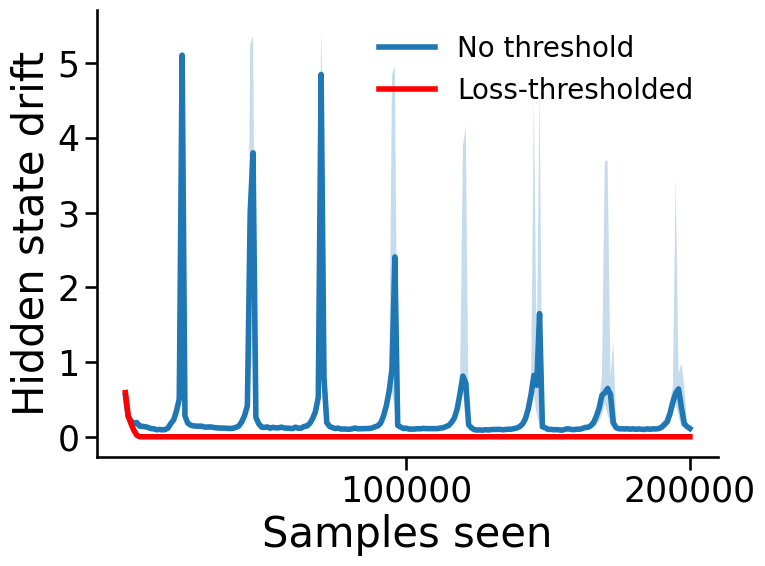

In [105]:
sns.set_context("talk")

# ---------- Load ----------
with open('../pickle_files/memory_drift_not_thresholded.pickle', 'rb') as f:
    df_not = pickle.load(f)

with open('../pickle_files/memory_drift_thresholded.pickle', 'rb') as f:
    df_thr = pickle.load(f)

# ---------- Ensure samples_seen exists ----------
def ensure_samples_seen(df, checkpoint_every=1000):
    df = df.copy()
    if "samples_seen" in df.columns:
        return df
    df["_idx"] = df.groupby("reps").cumcount() + 1
    df["samples_seen"] = df["_idx"] * checkpoint_every
    return df.drop(columns="_idx")

df_not = ensure_samples_seen(df_not)
df_thr = ensure_samples_seen(df_thr)

# ---------- Limit to 200k samples ----------
df_not = df_not[df_not["samples_seen"] <= 200000]
df_thr = df_thr[df_thr["samples_seen"] <= 200000]

# ---------- Compute median + IQR ----------
def compute_stats(df):
    g = df.groupby("samples_seen")["Drift"]
    x = g.median().index.values
    median = g.median().values
    q25 = g.quantile(0.25).values
    q75 = g.quantile(0.75).values
    return x, median, q25, q75

x_not, m_not, q25_not, q75_not = compute_stats(df_not)
x_thr, m_thr, q25_thr, q75_thr = compute_stats(df_thr)

# ---------- Plot ----------
fig, ax = plt.subplots(figsize=(8,6))

ax.plot(x_not, m_not, linewidth=4, label="No threshold")
ax.fill_between(x_not, q25_not, q75_not, alpha=0.25)

ax.plot(x_thr, m_thr, linewidth=4, c='r', label="Loss-thresholded")
ax.fill_between(x_thr, q25_thr, q75_thr, color='r', alpha=0.25)

ax.set_xlabel("Samples seen", fontsize=30)
ax.set_ylabel("Hidden state drift", fontsize=30)

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

ax.set_xticks([100000, 200000])
ax.tick_params(labelsize=25)
ax.legend(loc="upper right", frameon=False, fontsize=20)

plt.tight_layout()

plt.savefig('../plots/hidden_state_drift.pdf', bbox_inches='tight')
plt.show()